# Laboratorio: Perceptrón Multicapa para Predicción de Campañas Bancarias
**Curso:** Sistemas Inteligentes  
**Herramientas:** Python, Jupyter Notebook, Scikit-Learn  
**Objetivo:** Clasificar si un cliente aceptará un depósito a plazo fijo utilizando una red neuronal MLP.

In [1]:
%pip install ucimlrepo pandas scikit-learn matplotlib joblib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importación de Librerías y Dependencias
Cargamos las herramientas necesarias para la manipulación de datos, preprocesamiento con pipelines, diseño de la red neuronal y cálculo de métricas de evaluación.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import joblib

## 2. Carga del Dataset desde el Repositorio UCI
Utilizamos la API de `ucimlrepo` para descargar directamente el conjunto de datos "Bank Marketing" (ID: 222). Extraemos las características (X) y las etiquetas objetivo (y).

In [3]:
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets.squeeze()

print('Dimensión de X (Características):', X.shape)
print('Dimensión de y (Target):', y.shape)
X.head()

Dimensión de X (Características): (45211, 16)
Dimensión de y (Target): (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


## 3. Exploración Inicial y Análisis de Balanceo
Agrupamos los datos temporalmente para analizar las dimensiones y evaluar si la variable objetivo está balanceada (proporción de clientes que dijeron "yes" frente a "no").

In [4]:
df = X.copy()
df['target'] = y

print("Distribución porcentual de la variable objetivo:")
print(df['target'].value_counts(normalize=True))
df.info()

Distribución porcentual de la variable objetivo:
target
no     0.883015
yes    0.116985
Name: proportion, dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  target       45211 non-null  str  
dtypes: int64(7), str

## 4. Preprocesamiento de Datos (Estandarización y Codificación)
Para que el Perceptrón Multicapa procese la información, separamos las variables:
*   **Numéricas:** Se normalizan usando `StandardScaler` para evitar problemas de escala en los gradientes.
*   **Categóricas:** Se transforman mediante `OneHotEncoder` a vectores binarios.
*   **Target:** Se codifica de texto ('yes'/'no') a valores binarios (1/0) con `LabelEncoder`.

In [5]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ])

print('Variables numéricas:', numeric_features)
print('Variables categóricas:', categorical_features)

Variables numéricas: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


C:\Users\dapdi\AppData\Local\Temp\ipykernel_21796\1714434807.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## 5. División del Dataset (Entrenamiento y Prueba)
Dividimos los datos usando una estrategia Hold-Out con un **70% para entrenamiento** y un **30% para prueba**. El parámetro `stratify` garantiza que se mantenga la misma proporción de clases en ambas particiones.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)
print('Tamaño de Train:', X_train.shape)
print('Tamaño de Test:', X_test.shape)

Tamaño de Train: (31647, 16)
Tamaño de Test: (13564, 16)


## 6. Configuración y Entrenamiento de la Arquitectura Base (MLP)
Definimos un pipeline que integra el preprocesamiento y el clasificador `MLPClassifier`. La arquitectura inicial consta de dos capas ocultas (16 y 8 neuronas), función de activación ReLU, optimizador Adam y `early_stopping=True` para prevenir el sobreajuste.

In [7]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp_model)
])

pipeline.fit(X_train, y_train)
print('¡Entrenamiento de la arquitectura base finalizado con éxito!')

¡Entrenamiento de la arquitectura base finalizado con éxito!


## 7. Evaluación del Modelo Base y Matriz de Confusión
Calculamos las métricas clave del rendimiento: Accuracy, Precision, Recall y F1-score. Adicionalmente, graficamos la **Matriz de Confusión** para visualizar cuántos aciertos y errores cometió el modelo por cada clase.

Accuracy : 0.9005
Precision: 0.6184
Recall   : 0.3900
F1-score : 0.4784

              precision    recall  f1-score   support

          no       0.92      0.97      0.94     11977
         yes       0.62      0.39      0.48      1587

    accuracy                           0.90     13564
   macro avg       0.77      0.68      0.71     13564
weighted avg       0.89      0.90      0.89     13564



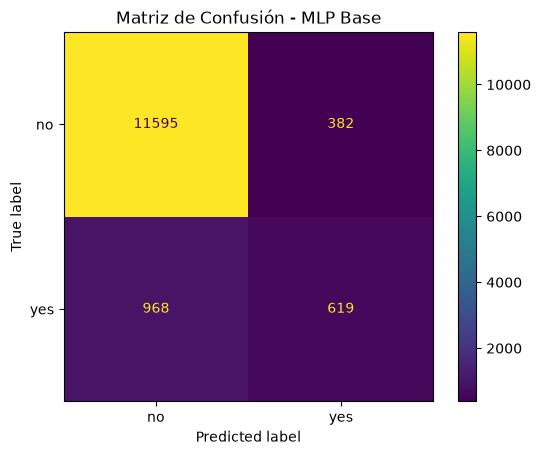

In [8]:
y_pred = pipeline.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}\n')

print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_encoder.classes_)
plt.title('Matriz de Confusión - MLP Base')
plt.show()

## 8. Curva de Pérdida (Loss Curve)
Graficamos la evolución del error (loss) a lo largo de cada iteración (época) de entrenamiento para verificar la correcta convergencia matemática del algoritmo de Backpropagation.

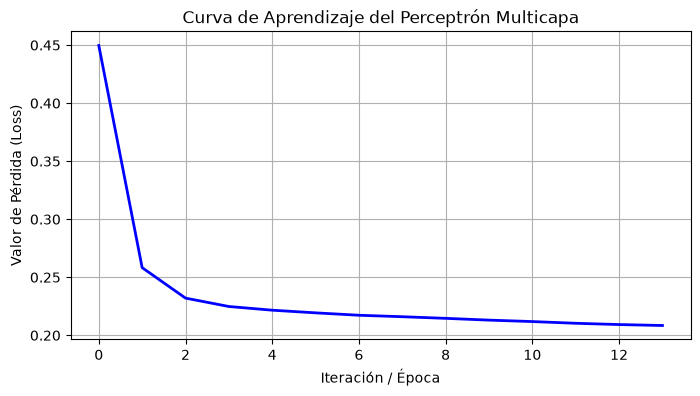

In [9]:
loss_curve = pipeline.named_steps['model'].loss_curve_
plt.figure(figsize=(8, 4))
plt.plot(loss_curve, color='blue', lw=2)
plt.xlabel('Iteración / Época')
plt.ylabel('Valor de Pérdida (Loss)')
plt.title('Curva de Aprendizaje del Perceptrón Multicapa')
plt.grid(True)
plt.show()

## 9. Comparación Experimental de Arquitecturas (Reto Experimental)
Entrenamos y evaluamos tres configuraciones de redes neuronales distintas:
1. Una capa oculta simple: `(8,)`
2. Dos capas ocultas (Base): `(16, 8)`
3. Tres capas ocultas profundas: `(32, 16, 8)`

El fin es analizar la variación del rendimiento respecto a la complejidad de la red.

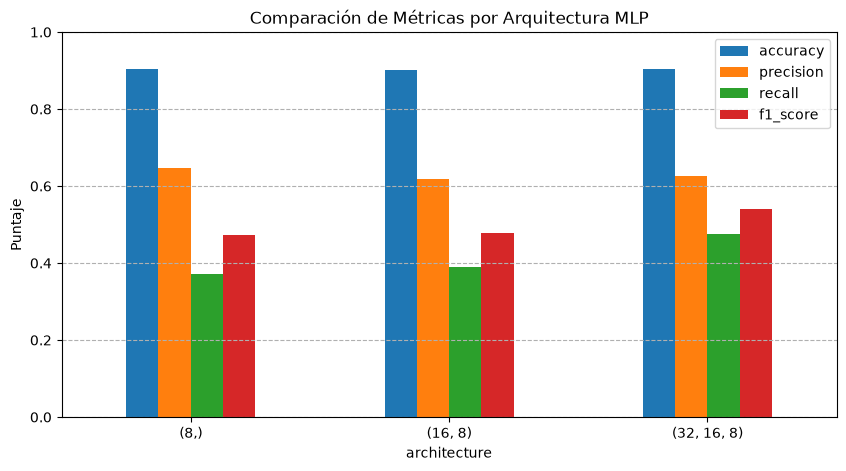

,architecture,accuracy,precision,recall,f1_score,iterations
0,"(8,)",0.902757,0.646608,0.372401,0.472611,16
1,"(16, 8)",0.900472,0.618382,0.390044,0.478362,14
2,"(32, 16, 8)",0.905264,0.625207,0.475110,0.539921,31


In [10]:
architectures = [(8,), (16, 8), (32, 16, 8)]
results = []

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True
    )
    
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    results.append({
        'architecture': str(arch),
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1_score': f1_score(y_test, preds),
        'iterations': pipe.named_steps['model'].n_iter_
    })

results_df = pd.DataFrame(results)

# Renderizar gráfico de barras
results_df.plot(x='architecture', y=['accuracy', 'precision', 'recall', 'f1_score'], kind='bar', figsize=(10, 5))
plt.title('Comparación de Métricas por Arquitectura MLP')
plt.ylabel('Puntaje')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

results_df

## 10. Almacenamiento y Serialización del Modelo Final
Guardamos nuestro Pipeline completo (preprocesamiento + red entrenada) en un archivo binario `.joblib` para permitir su posterior despliegue o puesta en producción.

In [11]:
joblib.dump(pipeline, 'mlp_bank_marketing_model.joblib')
print('¡Modelo guardado correctamente como mlp_bank_marketing_model.joblib!')

¡Modelo guardado correctamente como mlp_bank_marketing_model.joblib!
